In [4]:
from pathlib import Path
import sqlite3

db_path = (Path.cwd().parent / "SQL" / "IFCAllData.db").resolve()
connection = sqlite3.connect(f"file:{db_path}?mode=ro", uri=True)

try:
    cursor = connection.execute(
        """
        SELECT name
        FROM sqlite_master
        WHERE type = 'table' AND name = 'IFCAllData-COBie'
        """
    )
    for row in cursor:
        print(row[0])
finally:
    connection.close()

IFCAllData-COBie


## Query SOURCE_FILE, NAME, GLOBALID, and COBie
Read the requested columns from the IFCAllData-COBie table without modifying the database, then print a 20-row preview containing the first 10 rows and the last 10 rows in fancy_grid format.

In [10]:
import pandas as pd
import sqlite3
from pathlib import Path
from tabulate import tabulate

db_path = (Path.cwd().parent / "SQL" / "IFCAllData.db").resolve()
connection = sqlite3.connect(f"file:{db_path}?mode=ro", uri=True)

try:
    query = '''
    SELECT SOURCE_FILE, NAME, GLOBALID, COBie
    FROM "IFCAllData-COBie"
    '''
    results = pd.read_sql_query(query, connection)
    preview = pd.concat([results.head(5), results.tail(10)], ignore_index=True)

    print("IFCAllData-COBie SQL Table preview: first 8 rows and last 10 rows")
    print(tabulate(preview, headers="keys", tablefmt="fancy_grid", showindex=False))
finally:
    connection.close()

IFCAllData-COBie SQL Table preview: first 8 rows and last 10 rows
╒══════════════════════════════════════════╤═══════════════════════════════════════════╤════════════════════════╤═════════════════════════════════════════════════════════════════╕
│ SOURCE_FILE                              │ NAME                                      │ GLOBALID               │ COBie                                                           │
╞══════════════════════════════════════════╪═══════════════════════════════════════════╪════════════════════════╪═════════════════════════════════════════════════════════════════╡
│ ACD-18040-ALL-ST-N2x3.json               │                                           │                        │                                                                 │
├──────────────────────────────────────────┼───────────────────────────────────────────┼────────────────────────┼─────────────────────────────────────────────────────────────────┤
│ ACD-18040-ALL-ST-N2x3.json      

## Bubble Chart by Name
Count rows for each non-empty NAME in the IFCAllData-COBie table and plot a bubble chart where bubble size is based on the count. This uses a read-only database connection.

,NAME,ROW_COUNT
0,Floor:250,1166
1,100x50x10PFC,1051
2,K-Series Bar Joist-Angle Web:16K6,678
3,Monolithic Run:175mm Depth,482
4,SFM-STB-BEN-STEEL_BEAM-533x210x122,441
...,...,...
241,W Shapes:W36x232,2
242,Assembled Stair:STS-SOD-Metal_Ladder,1
243,Cast-In-Place Stair:CCS_ACD_1100mm_Structure,1
244,Cast-In-Place Stair:CCS_SOD_1550mm_Structure,1


Total non-empty names plotted: 246
Total rows counted: 12455


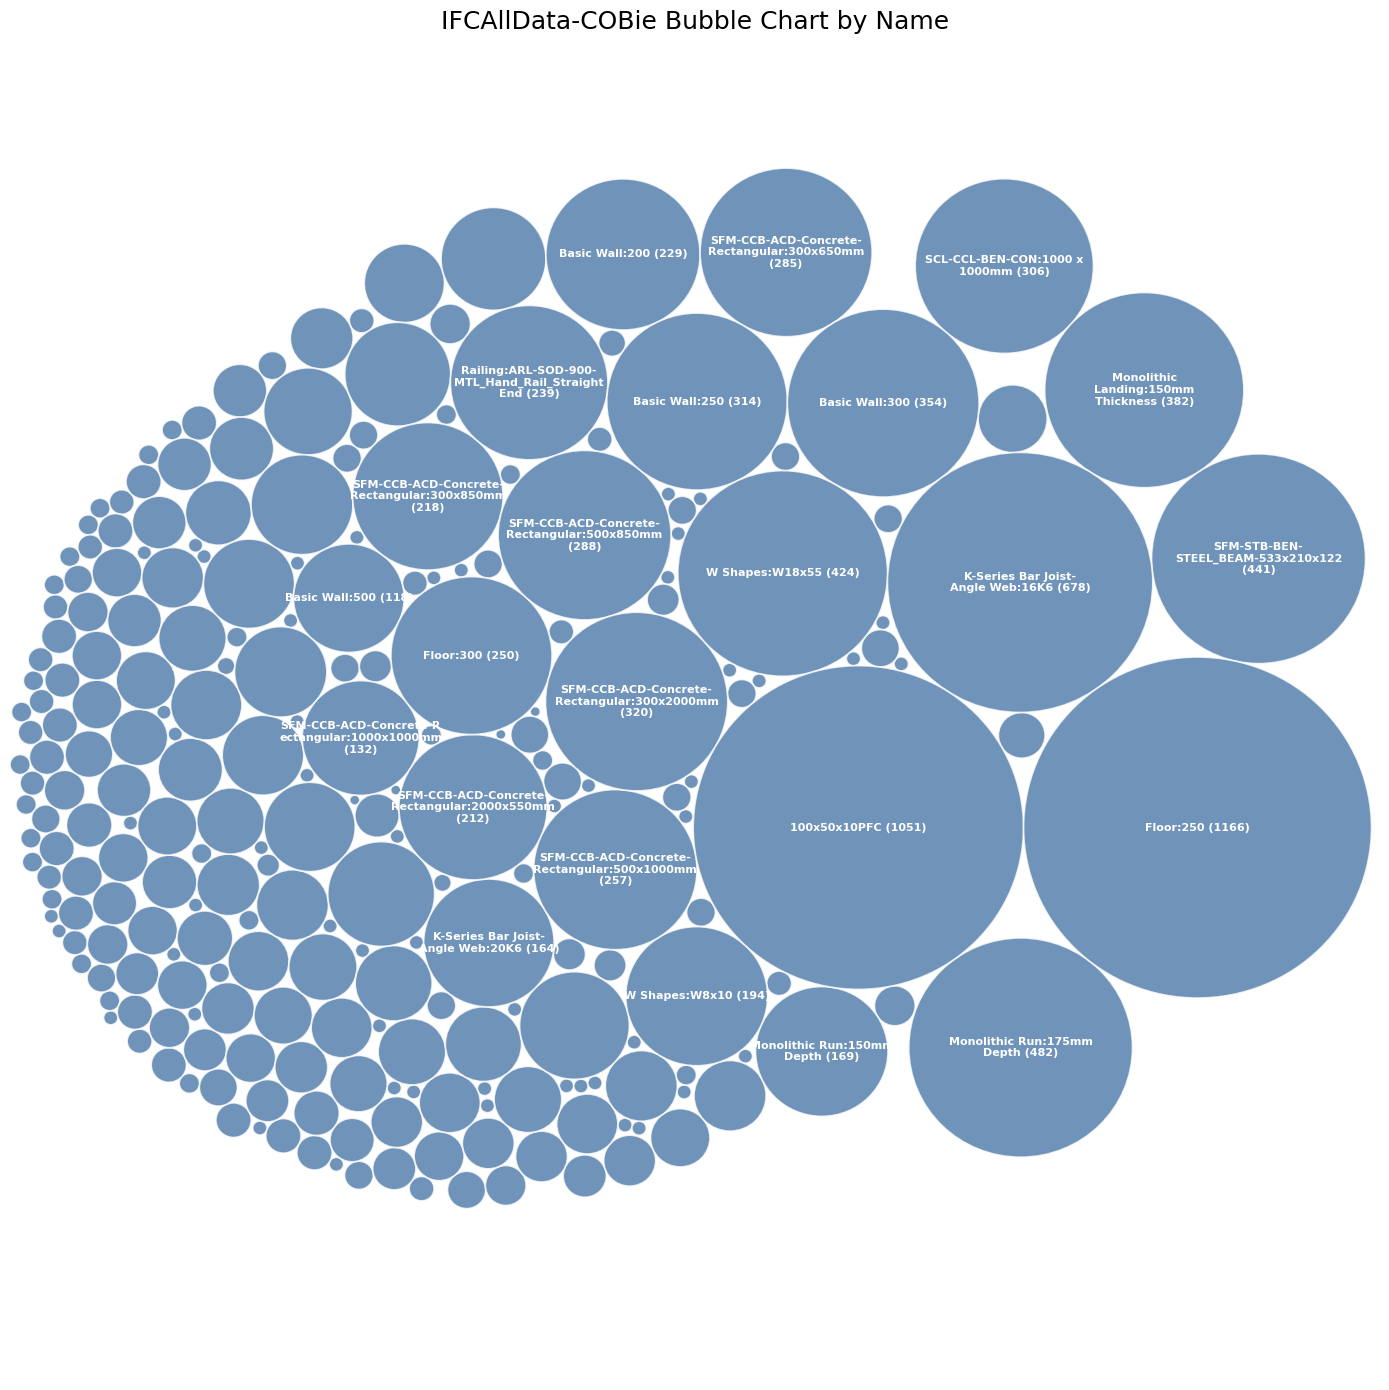

In [12]:
import sqlite3
import textwrap
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

try:
    import circlify
except ImportError:
    print("Package 'circlify' is not installed. Run: %pip install circlify")
else:
    db_path = (Path.cwd().parent / "SQL" / "IFCAllData.db").resolve()
    connection = sqlite3.connect(f"file:{db_path}?mode=ro", uri=True)

    try:
        query = '''
        SELECT TRIM(NAME) AS NAME, COUNT(*) AS ROW_COUNT
        FROM "IFCAllData-COBie"
        WHERE TRIM(COALESCE(NAME, '')) <> ''
        GROUP BY TRIM(NAME)
        ORDER BY ROW_COUNT DESC, TRIM(NAME)
        '''
        name_counts = pd.read_sql_query(query, connection)
    finally:
        connection.close()

    if name_counts.empty:
        print("No NAME data available to plot.")
    else:
        display(name_counts)

        circles_data = [
            {"id": str(row["NAME"]), "datum": int(row["ROW_COUNT"])}
            for _, row in name_counts.iterrows()
            if pd.notna(row["NAME"]) and int(row["ROW_COUNT"]) > 0
        ]

        circles = circlify.circlify(
            circles_data,
            show_enclosure=False,
            target_enclosure=circlify.Circle(x=0, y=0, r=1),
        )

        fig, ax = plt.subplots(figsize=(14, 14))
        ax.set_title("IFCAllData-COBie Bubble Chart by Name", fontsize=18)
        ax.axis("off")

        lim = max(
            max(abs(circle.x) + circle.r, abs(circle.y) + circle.r)
            for circle in circles
        )
        ax.set_xlim(-lim, lim)
        ax.set_ylim(-lim, lim)

        for circle in circles:
            if circle.level != 1:
                continue

            x, y, r = circle
            name_value = str(circle.ex["id"]).strip()
            row_count = int(circle.ex["datum"])
            label = textwrap.fill(f"{name_value}\n({row_count})", width=22)

            ax.add_patch(
                plt.Circle(
                    (x, y),
                    r,
                    alpha=0.8,
                    linewidth=1.2,
                    edgecolor="white",
                    facecolor="#4C78A8",
                )
            )

            if r > 0.08:
                ax.annotate(
                    label,
                    (x, y),
                    ha="center",
                    va="center",
                    fontsize=8,
                    color="white",
                    weight="bold",
                )

        print(f"Total non-empty names plotted: {len(name_counts)}")
        print(f"Total rows counted: {int(name_counts['ROW_COUNT'].sum())}")

        plt.tight_layout()
        plt.show()